# Data Preprocessing & Feature Engineering



## 0. Data Preparation
### 0.1 Check for Duplicate Patient Records
Based on the 'patient_nbr' column, we need to identify and handle duplicate patient records.

In [1]:
import pandas as pd
Original_X = pd.read_csv(f"diabetes.csv")
# How to determine if patient records are duplicated? Is it possible that patient_nbr is duplicated but record content is different? Code verification as follows:

# 1. Check if patient_nbr has duplicates
print("Number of duplicate patient numbers:", Original_X['patient_nbr'].duplicated().sum())

# 2. Check if there are completely duplicate records
print("Number of completely duplicate records:", Original_X.duplicated().sum())

C:\Users\luisl\AppData\Local\Temp\ipykernel_38948\1734062996.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  Original_X = pd.read_csv(f"diabetes.csv")


Number of duplicate patient numbers: 30248
Number of completely duplicate records: 0


### 0.2 Load Feature Dataset

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

C:\Users\luisl\AppData\Local\Temp\ipykernel_38948\3903388772.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('diabetes.csv')


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 1. Missing Value Handling
### 1.1 Remove High Missing Value Columns
Based on EDA analysis, the following columns have high missing proportions:
- weight (96.9% missing)
- max_glu_serum (94.7% missing)
- A1Cresult (83.3% missing)
- medical_specialty (49.1% missing)
- payer_code (39.6% missing)

In [3]:
# Remove columns with high missing values
cols_to_drop = ['weight', 'max_glu_serum', 'A1Cresult', 'medical_specialty', 'payer_code']
df = df.drop(columns=cols_to_drop)
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 1.2 Remove Single-Value Columns
Based on EDA analysis, 'citoglipton' and 'examide' have only one unique value


In [4]:
# Remove columns with only one unique value
df = df.drop(columns=['citoglipton', 'examide'])
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### 1.3 Handling Remaining Missing Values

According to EDA analysis, the following columns still have missing values:

- race (2.2% missing)
- diag_3 (1.4% missing)
- diag_2 (0.4% missing)
- diag_1 (0.0% missing)

For the "race" column, which is a categorical feature and already includes an "Other" category, we will assign all missing values to "Other";


In [5]:
df['race'] = df['race'].fillna('Other')

For the columns "diag_1", "diag_2", and "diag_3", although they are defined as categorical features in the original dataset, EDA shows that each of them contains over 700 unique categories. Therefore, it is no longer appropriate to treat them as categorical variables. Since these columns are represented by ICD9 codes, which are typically continuous numbers ranging from 0 to 999 (each corresponding to a specific diagnosis), it is more suitable to convert them into numerical features. Additionally, as a special mapping, codes that start with 'E' or 'V' will be uniformly mapped to 1000.

Another issue during the data type conversion is that some codes are in float format. According to ICD9 code rules, we can safely discard the decimal part and keep only the integer portion, as the digits after the decimal point only indicate subcategories of a major disease and do not affect the main intent of the data.

In [6]:
def icd9_to_numeric(icd_code):
    if pd.isna(icd_code) or icd_code == 'Unknown':
        return 0
    code_str = str(icd_code)
    if code_str.startswith('E') or code_str.startswith('V'):
        return 1000
    try:
        # Keep only the integer part before decimal point
        return int(float(code_str))
    except:
        return 0 

# Process three diagnosis features
df['diag_1_numeric'] = df['diag_1'].apply(icd9_to_numeric)
df['diag_2_numeric'] = df['diag_2'].apply(icd9_to_numeric)
df['diag_3_numeric'] = df['diag_3'].apply(icd9_to_numeric)

# Delete diag_1, diag_2, diag_3 columns
df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])
df.head()

# Rename diag_1_numeric, diag_2_numeric, diag_3_numeric columns to diag_1, diag_2, diag_3
df = df.rename(columns={'diag_1_numeric': 'diag_1', 'diag_2_numeric': 'diag_2', 'diag_3_numeric': 'diag_3'})
df.head()


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,diag_1,diag_2,diag_3
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,...,No,No,No,No,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Ch,Yes,>30,276,250,255
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,No,No,No,No,No,Yes,NO,648,250,1000
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Ch,Yes,NO,8,250,403
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,No,No,No,No,Ch,Yes,NO,197,157,250


After conversion to numeric, the histograms of these three columns show that they can indeed be treated as numeric types.

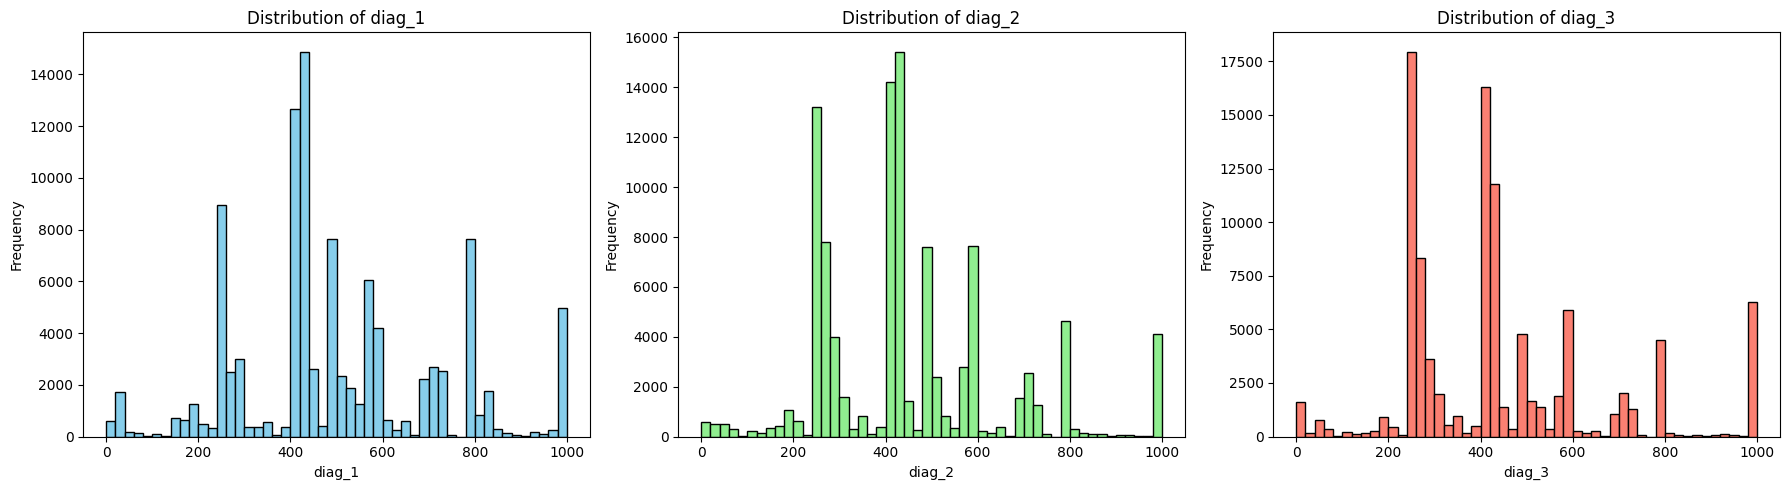

In [7]:
# Plot distribution of diag_1, diag_2, diag_3
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.hist(df['diag_1'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of diag_1')
plt.xlabel('diag_1')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(df['diag_2'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Distribution of diag_2')
plt.xlabel('diag_2')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(df['diag_3'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of diag_3')
plt.xlabel('diag_3')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [8]:
# Check if there are still missing values in the dataset
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
if not missing_values.empty:
    print("Missing values still exist in the dataset:")
    print(missing_values)
else:
    print("No missing values remaining in the dataset.")


No missing values remaining in the dataset.


## 2. Re-encoding and Mapping
### 2.1 Re-encoding `admission_type_id`, `discharge_disposition_id`, `admission_source_id`

Based on EDA analysis, although admission_type_id, discharge_disposition_id, and admission_source_id are listed as numeric features in the original dataset, and the dataset descriptions are as follows:

- admission_type_id: Type of admission (1=Emergency, 2=Urgent, 3=Elective, etc.)
- discharge_disposition_id: Discharge destination (1=Home, 3=SNF, 6=Home with service, etc.)
- admission_source_id: Source of admission (1=Physician referral, 7=Emergency room, etc.)

However, based on the histograms and EDA analysis of these three features, each number in these columns represents a specific category, and there is no mathematical relationship between ID=1 and ID=2. Some categories appear very frequently while others are rare. Therefore, they should be treated as categorical features, so we re-encode admission type, discharge type, and admission source into fewer categories.

In [9]:
# First analyze the value distributions of admission_type_id, discharge_disposition_id, and admission_source_id to determine where to truncate for merging.
print("admission_type_id value counts:")
print(df['admission_type_id'].value_counts())
print("\ndischarge_disposition_id value counts:")
print(df['discharge_disposition_id'].value_counts())
print("\nadmission_source_id value counts:")
print(df['admission_source_id'].value_counts())

admission_type_id value counts:
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64

discharge_disposition_id value counts:
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64

admission_source_id value counts:
admission_source_id
7     57494
1     29565
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64


Based on the value distribution analysis above, re-encode admission type, discharge type, and admission source as follows:

- admission_type_id: 1=Emergency, 2=Urgent, 3=Elective, 4=other
- discharge_disposition_id: 1=Home, 3=SNF, 6=Home with service, 4=other
- admission_source_id: 1=Physician referral, 7=Emergency room, 4=other


In [10]:
# Merge categories other than [1,2,3] for admission_type_id as 'other'
df['admission_type_id'] = df['admission_type_id'].apply(lambda x: '4' if x not in [1,2,3] else x)
df['admission_type_id'].value_counts()
# Merge categories other than [1,3,6] for discharge_disposition_id as 'other'
df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(lambda x: '4' if x not in [1,3,6] else x)
df['discharge_disposition_id'].value_counts()
# Merge categories other than [1,7] for admission_source_id as 'other'
df['admission_source_id'] = df['admission_source_id'].apply(lambda x: '4' if x not in [1,7] else x)
df['admission_source_id'].value_counts()


admission_source_id
7    57494
1    29565
4    14707
Name: count, dtype: int64

### 2.2 Convert Age Intervals to Midpoint Values

In [11]:
def age_to_mid(age_str):
    # age_str is in the format "[20-30)"
    if isinstance(age_str, str) and '-' in age_str:
        nums = age_str.replace('[','').replace(')','').split('-')
        return (int(nums[0]) + int(nums[1])) // 2
    else:
        return None

df['age'] = df['age'].apply(age_to_mid)
df['age'].head()



0     5
1    15
2    25
3    35
4    45
Name: age, dtype: int64

### 2.3 Convert Target Variable to Binary Classification

Merge ">30 days" and "No readmission" categories into a single "No readmission within 30 days" category


In [12]:
# Convert readmitted column to binary classification: merge ">30" and "NO" as "NO", "<=30" as "YES"
df_target = pd.read_csv('diabetes.csv')
df_target.head()
df_target['readmitted'] = df_target['readmitted'].apply(lambda x: 'YES' if x == '<30' else 'NO')
df_target['readmitted'].value_counts()


C:\Users\luisl\AppData\Local\Temp\ipykernel_38948\1778527925.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_target = pd.read_csv('diabetes.csv')


readmitted
NO     90409
YES    11357
Name: count, dtype: int64

## 3. Feature Engineering
### 3.1 Processing Diagnosis-Related Columns

Since diag_3 represents an "additional secondary diagnosis" and has relatively low clinical value, we remove diag_3 and only use the other two sets of diagnosis codes. Each diagnosis level is mapped to a numerical representation based on specific criteria, as previously implemented.

Pearson correlation coefficient between diag_2 and diag_3:
          diag_2    diag_3
diag_2  1.000000  0.080952
diag_3  0.080952  1.000000


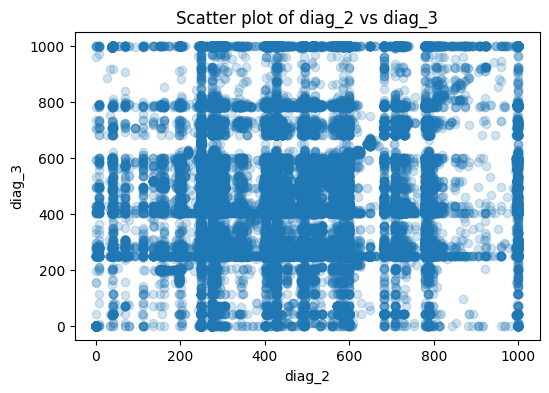

Pearson correlation coefficient between diag_1 and diag_2:
          diag_1    diag_2
diag_1  1.000000  0.038742
diag_2  0.038742  1.000000


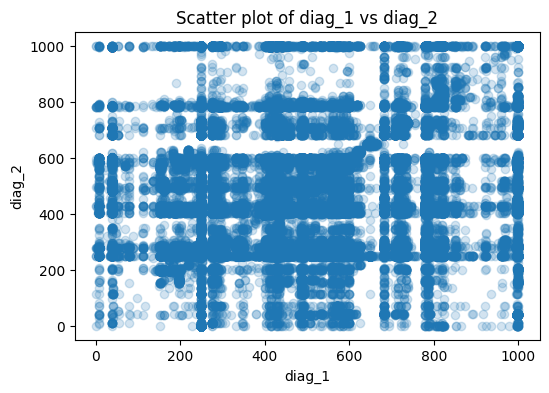

In [13]:
# diag_2 and diag_3 are already numeric, so we can directly analyze their correlation
correlation = df[['diag_2', 'diag_3']].corr(method='pearson')
print("Pearson correlation coefficient between diag_2 and diag_3:")
print(correlation)

# Visualize the scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['diag_2'], df['diag_3'], alpha=0.2)
plt.xlabel('diag_2')
plt.ylabel('diag_3')
plt.title('Scatter plot of diag_2 vs diag_3')
plt.show()

# Explanation: Originally, diag_2 and diag_3 were categorical variables with a very large number of categories (900+), making direct correlation analysis impractical. After converting them to numeric values, we can use the Pearson correlation coefficient to measure their linear relationship. While this approach may not fully capture the complexity of the original categorical variables, Pearson provides a straightforward and intuitive metric for correlation when dealing with a large number of categories that have been numerically encoded. If the variables remain categorical or ordinal, or if you are concerned about the ordinal assumptions introduced by numeric encoding, you might consider using Cramér's V or frequency-based correlation methods. However, in this context, Pearson is a commonly used and easily interpretable choice.

# diag_1 and diag_2 are already numeric, so we can directly analyze their correlation
correlation_1_2 = df[['diag_1', 'diag_2']].corr(method='pearson')
print("Pearson correlation coefficient between diag_1 and diag_2:")
print(correlation_1_2)

# Visualize the scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df['diag_1'], df['diag_2'], alpha=0.2)
plt.xlabel('diag_1')
plt.ylabel('diag_2')
plt.title('Scatter plot of diag_1 vs diag_2')
plt.show()

# Explanation: diag_1 and diag_2 were originally categorical variables with many categories. After converting them to numeric values, we can use the Pearson correlation coefficient to assess their linear relationship. Although this method may not fully reflect the complexity of the original categorical variables, Pearson provides a simple and intuitive measure of correlation when dealing with a large number of numerically encoded categories.


In [14]:
# Remove the diag_3 column
df = df.drop('diag_3', axis=1)

### 3.2 Calculating the Total Number of Medications Used by Each Patient

The original dataset records the usage of 23 different medications. From previous EDA, we observed that most patients use only one type of medication, primarily metformin and insulin. This suggests that the specific type of drug is less critical, so instead of analyzing the effect of each medication individually, we focus on the total number of medications used by each patient. Additionally, the dataset includes a column `diabetesMed` indicating whether diabetes-related medication was prescribed, which further supports the validity of this approach.


In [15]:
# add a new column 'num_drugs' in df
drug_columns = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
] # exclude 'citoglipton' and 'examide' for they had been removed

# count the total number of medications used by each patient (as long as it's not "No", it's considered used)
df['num_drugs'] = df[drug_columns].apply(lambda row: sum(row != 'No'), axis=1)

# check the basic statistics of the new column
print("num_drugs 列的基本统计信息：")
print(df['num_drugs'].describe())
print(f"\nnum_drugs 的分布：")
print(df['num_drugs'].value_counts().sort_index())

num_drugs 列的基本统计信息：
count    101766.000000
mean          1.179706
std           0.920190
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_drugs, dtype: float64

num_drugs 的分布：
num_drugs
0    23403
1    47314
2    21873
3     7778
4     1335
5       58
6        5
Name: count, dtype: int64


从num_drugs 的分布看，大多数患者不吃药或者最多吃2种药。说明这项统计非常有意义。

In [16]:
# delete the drug columns
df = df.drop(drug_columns, axis=1)
df.head()


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,change,diabetesMed,readmitted,diag_1,diag_2,num_drugs
0,2278392,8222157,Caucasian,Female,5,4,4,1,1,41,...,0,0,0,1,No,No,NO,250,0,0
1,149190,55629189,Caucasian,Female,15,1,1,7,3,59,...,0,0,0,9,Ch,Yes,>30,276,250,1
2,64410,86047875,AfricanAmerican,Female,25,1,1,7,2,11,...,2,0,1,6,No,Yes,NO,648,250,1
3,500364,82442376,Caucasian,Male,35,1,1,7,2,44,...,0,0,0,7,Ch,Yes,NO,8,250,1
4,16680,42519267,Caucasian,Male,45,1,1,7,1,51,...,0,0,0,5,Ch,Yes,NO,197,157,2


### 3.3 Creating the Service Utilization Variable (Total of Outpatient, Emergency, and Inpatient Visits)

In [17]:
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df = df.drop(['number_outpatient', 'number_emergency', 'number_inpatient'], axis=1)
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,change,diabetesMed,readmitted,diag_1,diag_2,num_drugs,service_utilization
0,2278392,8222157,Caucasian,Female,5,4,4,1,1,41,0,1,1,No,No,NO,250,0,0,0
1,149190,55629189,Caucasian,Female,15,1,1,7,3,59,0,18,9,Ch,Yes,>30,276,250,1,0
2,64410,86047875,AfricanAmerican,Female,25,1,1,7,2,11,5,13,6,No,Yes,NO,648,250,1,3
3,500364,82442376,Caucasian,Male,35,1,1,7,2,44,1,16,7,Ch,Yes,NO,8,250,1,0
4,16680,42519267,Caucasian,Male,45,1,1,7,1,51,0,8,5,Ch,Yes,NO,197,157,2,0


### 3.4 Merge admission_type_id and admission_source_id to create a combined feature: admission_type_source

Cramér's V between admission_type_id and admission_source_id: 0.6123


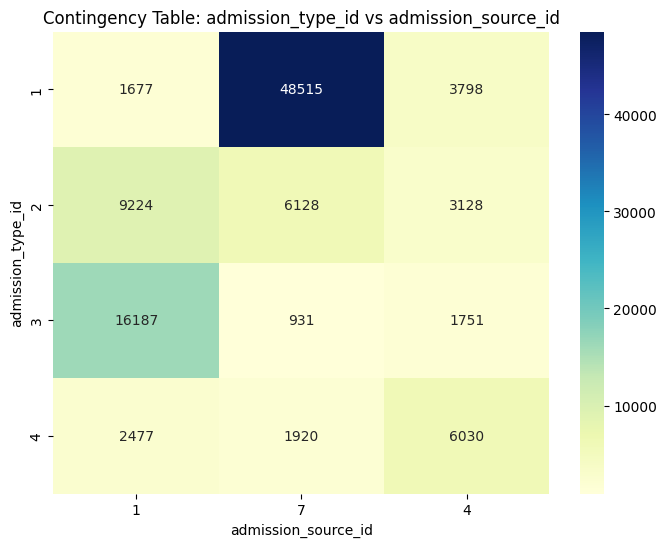

In [18]:
# Correlation analysis (Cramér's V) and visualization between admission type (admission_type_id) and admission source (admission_source_id)

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def cramers_v(x, y):
    """Calculate Cramér's V to measure correlation between two categorical variables"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Bias correction
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

def plot_contingency_heatmap(df, col1, col2):
    """Plot contingency table heatmap for two categorical variables"""
    contingency = pd.crosstab(df[col1], df[col2])
    plt.figure(figsize=(8, 6))
    sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'Contingency Table: {col1} vs {col2}')
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()

# Check if required columns exist
if {'admission_type_id', 'admission_source_id'}.issubset(df.columns):
    v = cramers_v(df['admission_type_id'], df['admission_source_id'])
    print(f"Cramér's V between admission_type_id and admission_source_id: {v:.4f}")
    plot_contingency_heatmap(df, 'admission_type_id', 'admission_source_id')
else:
    print("admission_type_id or admission_source_id not found in DataFrame.")


Cramér's V = 0.6123 indeed indicates strong correlation between these two features, so we group the 4 most correlated combinations from the heatmap and group others as 'other' to avoid multicollinearity issues.
Therefore, we combine `admission_type_id` and `admission_source_id`:

Original:
- admission_type_id: 1=Emergency, 2=Urgent, 3=Elective, 4=other
- admission_source_id: 1=Physician referral, 7=Emergency room, 4=other

Create combined feature: admission_type_source

- Emergency_ER: admission_type == 1 and admission_source == 7
- Urgent_Physician: admission_type == 2 and admission_source == 1
- Elective_Physician: admission_type == 3 and admission_source == 1
- Urgent_ER: admission_type == 2 and admission_source == 7
- Other_Combination


In [19]:
# Create combined feature: admission_type_source
def create_admission_combination(row):
    admission_type = row['admission_type_id']
    admission_source = row['admission_source_id']
    
    # Combinations based on business logic
    if admission_type == 1 and admission_source == 7:  # Emergency + ER
        return 'Emergency_ER'
    elif admission_type == 2 and admission_source == 1:  # Urgent + Physician
        return 'Urgent_Physician'
    elif admission_type == 3 and admission_source == 1:  # Elective + Physician
        return 'Elective_Physician'
    elif admission_type == 2 and admission_source == 7:  # Urgent + ER
        return 'Urgent_ER'
    else:
        return 'Other_Combination'

# Apply combined feature
df['admission_type_source'] = df.apply(create_admission_combination, axis=1)

# Delete original two columns
df.drop(['admission_type_id', 'admission_source_id'], axis=1, inplace=True)

df.head()

,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,change,diabetesMed,readmitted,diag_1,diag_2,num_drugs,service_utilization,admission_type_source
0,2278392,8222157,Caucasian,Female,5,4,1,41,0,1,1,No,No,NO,250,0,0,0,Other_Combination
1,149190,55629189,Caucasian,Female,15,1,3,59,0,18,9,Ch,Yes,>30,276,250,1,0,Emergency_ER
2,64410,86047875,AfricanAmerican,Female,25,1,2,11,5,13,6,No,Yes,NO,648,250,1,3,Emergency_ER
3,500364,82442376,Caucasian,Male,35,1,2,44,1,16,7,Ch,Yes,NO,8,250,1,0,Emergency_ER
4,16680,42519267,Caucasian,Male,45,1,1,51,0,8,5,Ch,Yes,NO,197,157,2,0,Emergency_ER


## 4. Data Standardization
### 4.1 Apply Standard Scaling to Numerical Features

In [20]:
# 对age, num_drugs, time_in_hospital, num_lab_procedures, num_procedures, num_medications, number_diagnoses, service_utilization 进行标准化
from sklearn.preprocessing import StandardScaler

# 需要标准化的数值特征
num_features = [
    'age', 'diag_1', 'diag_2', 'num_drugs', 'time_in_hospital', 'num_lab_procedures',
    'num_procedures', 'num_medications', 'number_diagnoses', 'service_utilization'
]

scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])
df.head()


,encounter_id,patient_nbr,race,gender,age,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,change,diabetesMed,readmitted,diag_1,diag_2,num_drugs,service_utilization,admission_type_source
0,2278392,8222157,Caucasian,Female,-3.824600,4,-1.137649,-0.106517,-0.785398,-1.848268,-3.321596,No,No,NO,-1.170927,-2.270434,-1.282031,-0.524817,Other_Combination
1,149190,55629189,Caucasian,Female,-3.197277,1,-0.467653,0.808384,-0.785398,0.243390,0.815784,Ch,Yes,>30,-1.049939,-1.012166,-0.195294,-0.524817,Emergency_ER
2,64410,86047875,AfricanAmerican,Female,-2.569954,1,-0.802651,-1.631351,2.145781,-0.371804,-0.735733,No,Yes,NO,0.681120,-1.012166,-0.195294,0.784215,Emergency_ER
3,500364,82442376,Caucasian,Male,-1.942632,1,-0.802651,0.045967,-0.199162,-0.002688,-0.218561,Ch,Yes,NO,-2.297047,-1.012166,-0.195294,-0.524817,Emergency_ER
4,16680,42519267,Caucasian,Male,-1.315309,1,-1.137649,0.401761,-0.785398,-0.986997,-1.252906,Ch,Yes,NO,-1.417557,-1.480242,0.891443,-0.524817,Emergency_ER


### 4.2 Apply One-Hot Encoding to Categorical Features

In [21]:
# check the data type of the dataset
print("Data type of the dataset: ")
print(df.dtypes)
print("\nShape of the dataset:", df.shape)

# find all categorical features
categorical_features = df.select_dtypes(include=['object']).columns
print(f"\nAll categorical features: {list(categorical_features)}")
df = pd.get_dummies(df, columns=categorical_features)
# convert all boolean columns to 0/1 format (int)
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

print("Current data type of each column:")
print(df.dtypes)

Data type of the dataset: 
encounter_id                  int64
patient_nbr                   int64
race                         object
gender                       object
age                         float64
discharge_disposition_id     object
time_in_hospital            float64
num_lab_procedures          float64
num_procedures              float64
num_medications             float64
number_diagnoses            float64
change                       object
diabetesMed                  object
readmitted                   object
diag_1                      float64
diag_2                      float64
num_drugs                   float64
service_utilization         float64
admission_type_source        object
dtype: object

Shape of the dataset: (101766, 19)

All categorical features: ['race', 'gender', 'discharge_disposition_id', 'change', 'diabetesMed', 'readmitted', 'admission_type_source']
Current data type of each column:
encounter_id                                  int64
patient_nbr    

## Todos:
## 5. Feature Selection
- Use the GWO algorithm from the zoofs library for feature selection

## 6. Cross-Validation Strategy
- Apply group k-fold cross-validation to ensure that all visit records from the same patient are kept within the same fold

## 7. Handling Class Imbalance
- Apply SMOTE (Synthetic Minority Over-sampling Technique) to the training set in each fold
- Balance the representation of readmission and non-readmission cases

## 5. Feature Selection
We will use the GWO algorithm from the zoofs library for feature selection. 

In [22]:
# ===== Step 5: Canonicalize data + GWO feature selection =====
from zoofs import GreyWolfOptimization
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

TEST_SIZE = 0.20
SEED      = 42
POP_SIZE  = 24
N_ITER    = 60

# ---- 5.1 Build y_bin, groups, X_use ----
s = df_target['readmitted'].astype(str).str.strip().str.upper()
uni = set(s.unique())
print("readmitted uniques:", sorted(uni))
y_bin = (s == 'YES').astype(int)

groups = df_target['patient_nbr'].values
drop_cols = [c for c in ['readmitted','readmitted_bin','patient_nbr','encounter_id'] if c in df_target.columns]
X_use = df_target.drop(columns=drop_cols, errors='ignore').select_dtypes(include=[np.number]).copy()
feature_names = list(X_use.columns)

print(f"df_target: {df_target.shape}  |  Feature Matrix: {X_use.shape}  |  Readmitted within 30 days: {int(y_bin.sum())}  |  Not readmitted within 30 days: {int((1-y_bin).sum())}")

# ---- 5.2 Hold-out split ----
sss = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
tr_idx, va_idx = next(sss.split(X_use, y_bin))
X_tr, y_tr = X_use.iloc[tr_idx].copy(), y_bin.iloc[tr_idx].copy()
X_va, y_va = X_use.iloc[va_idx].copy(), y_bin.iloc[va_idx].copy()
print(
    "Hold-out classes ->\n train:",
    y_tr.replace({0:"Not readmitted within 30 days", 1:"Readmitted within 30 days"}).value_counts().to_dict(),
    "|\n valid:",
    y_va.replace({0:"Not readmitted within 30 days", 1:"Readmitted within 30 days"}).value_counts().to_dict(),
)


# ---- baseline AUC (all features) ----
base_auc = roc_auc_score(
    y_va,
    LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")
        .fit(X_tr, y_tr)
        .predict_proba(X_va)[:, 1]
)
print(f"Baseline AUC (all features): {base_auc:.3f}")

# ---- 5.3 GWO objective (maximize AUC) and capture best feature list ----
_best = {"auc": 0.0, "features": None}

def objective_auc_max(_unused_model, X_tr_sel, y_tr_sel, X_va_sel, y_va_sel):
    # guards
    if X_tr_sel.shape[1] == 0 or X_va_sel.shape[1] == 0:
        return 0.0
    if y_tr_sel.nunique() < 2 or y_va_sel.nunique() < 2:
        return 0.0
    try:
        lr = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")
        lr.fit(X_tr_sel, y_tr_sel)
        auc = roc_auc_score(y_va_sel, lr.predict_proba(X_va_sel)[:, 1])
    except Exception:
        return 0.0
    if np.isfinite(auc) and auc > _best["auc"]:
        _best["auc"] = float(auc)
        _best["features"] = list(X_tr_sel.columns)  # capture names here
    return float(max(0.0, min(1.0, auc)))  # zoofs maximizes this

# ---- 5.4 Run GWO ----
gwo = GreyWolfOptimization(
    objective_function=objective_auc_max,
    n_iteration=N_ITER, population_size=POP_SIZE,
    method=1, minimize=False, logger=None
)
gwo.fit(LogisticRegression(max_iter=2000), X_tr, y_tr, X_va, y_va, verbose=True)

# ---- 5.5 Materialize selection ----
if not _best["features"]:
    print("No improvement captured; using top-20 variance as fallback.")
    selected_features = list(X_use.var().sort_values(ascending=False).head(min(20, X_use.shape[1])).index)
else:
    selected_features = _best["features"]

X_sel = X_use[selected_features]
print(f"GWO selected {len(selected_features)} / {X_use.shape[1]} features; best hold-out AUC = {_best['auc']:.3f}")
for i, f in enumerate(selected_features, 1):
    print(f"{i:2d}. {f}")


readmitted uniques: ['NO', 'YES']
df_target: (101766, 50)  |  Feature Matrix: (101766, 11)  |  Readmitted within 30 days: 11357  |  Not readmitted within 30 days: 90409
Hold-out classes ->
 train: {'Not readmitted within 30 days': 72326, 'Readmitted within 30 days': 9086} |
 valid: {'Not readmitted within 30 days': 18083, 'Readmitted within 30 days': 2271}
Baseline AUC (all features): 0.641


 [ 2025-10-04 20:42:44,815 ] Finished iteration #0 with objective value 0.641138518938055. Current best value is 0.641138518938055 
 [ 2025-10-04 20:42:48,879 ] Finished iteration #1 with objective value 0.6413844371858097. Current best value is 0.6413844371858097 
 [ 2025-10-04 20:42:50,284 ] Finished iteration #2 with objective value 0.6414406752483102. Current best value is 0.6414406752483102 
 [ 2025-10-04 20:42:50,382 ] Finished iteration #3 with objective value 0.6414406752483102. Current best value is 0.6414406752483102 
 [ 2025-10-04 20:42:50,490 ] Finished iteration #4 with objective value 0.6414406752483102. Current best value is 0.6414406752483102 
 [ 2025-10-04 20:42:50,582 ] Finished iteration #5 with objective value 0.6414406752483102. Current best value is 0.6414406752483102 
 [ 2025-10-04 20:42:50,675 ] Finished iteration #6 with objective value 0.6414406752483102. Current best value is 0.6414406752483102 
 [ 2025-10-04 20:42:50,771 ] Finished iteration #7 with objectiv

GWO selected 10 / 11 features; best hold-out AUC = 0.641
 1. admission_type_id
 2. discharge_disposition_id
 3. admission_source_id
 4. time_in_hospital
 5. num_lab_procedures
 6. num_procedures
 7. num_medications
 8. number_emergency
 9. number_inpatient
10. number_diagnoses


## 6. Cross-Validation Strategy
- Apply group k-fold cross-validation to ensure that all visit records from the same patient are kept within the same fold

In [23]:
# ===== 6) Cross-Validation Strategy — GroupKFold (no SMOTE) =====
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_validate, cross_val_predict
from sklearn.metrics import f1_score, precision_score, average_precision_score, recall_score, confusion_matrix

# --- Use selected features from Step 5 ---
X_cv = X_sel
y_cv = y_bin

# --- Pipeline: scale inside CV; class_weight='balanced' for imbalance ---
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")),
])

# --- GroupKFold splitter ---
cv = GroupKFold(n_splits=5)

# --- 6A. Fold-wise metrics via cross_validate (fast summary) ---
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}
cv_res = cross_validate(
    pipe, X_cv, y_cv,
    groups=groups, cv=cv, scoring=scoring,
    return_train_score=False, n_jobs=-1
)

print("GroupKFold (no SMOTE) — fold means ± std")
for k, lab in [("roc_auc","ROC-AUC"), ("pr_auc","PR-AUC"), ("f1","F1"), ("precision","Precision"), ("recall","Recall")]:
    mu, sd = cv_res[f"test_{k}"].mean(), cv_res[f"test_{k}"].std()
    print(f"  {lab:9}: {mu:.3f} ± {sd:.3f}")

# --- 6B. Out-of-fold predictions for overall metrics & confusion matrix ---
# This gives each sample a prediction from a model that never saw that sample.
oof_proba = cross_val_predict(
    pipe, X_cv, y_cv, groups=groups, cv=cv,
    method="predict_proba", n_jobs=-1
)[:, 1]

# Overall threshold-free scores
oof_roc  = roc_auc_score(y_cv, oof_proba)
oof_pra  = average_precision_score(y_cv, oof_proba)

# Thresholded metrics at default 0.5 
oof_pred = (oof_proba >= 0.5).astype(int)
oof_f1   = f1_score(y_cv, oof_pred)
oof_prec = precision_score(y_cv, oof_pred, zero_division=0)
oof_rec  = recall_score(y_cv, oof_pred)
cm       = confusion_matrix(y_cv, oof_pred)

print("\nOut-of-fold metrics (threshold = 0.50)")
print(f"  ROC-AUC : {oof_roc:.3f}")
print(f"  PR-AUC  : {oof_pra:.3f}")
print(f"  F1      : {oof_f1:.3f}")
print(f"  Precision: {oof_prec:.3f}")
print(f"  Recall  : {oof_rec:.3f}")
print("  Confusion matrix [[TN, FP], [FN, TP]]:")
print(cm)
print("Note that this is before balancing")

GroupKFold (no SMOTE) — fold means ± std
  ROC-AUC  : 0.637 ± 0.008
  PR-AUC   : 0.195 ± 0.010
  F1       : 0.254 ± 0.009
  Precision: 0.172 ± 0.007
  Recall   : 0.491 ± 0.011

Out-of-fold metrics (threshold = 0.50)
  ROC-AUC : 0.637
  PR-AUC  : 0.194
  F1      : 0.254
  Precision: 0.172
  Recall  : 0.492
  Confusion matrix [[TN, FP], [FN, TP]]:
[[63467 26942]
 [ 5775  5582]]
Note that this is before balancing


In [25]:
# ===== 7) Handling Class Imbalance — GroupKFold + SMOTE (leakage-safe) =====
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_recall_curve

X_eval = X_sel
y_eval = y_bin

# --- Pipeline: scale -> SMOTE (train folds only) -> classifier ---
# Note: k_neighbors=3 is a safe default when some folds have few minority samples.
pipe = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  SMOTE(random_state=42, k_neighbors=3, sampling_strategy="auto")),
    ("clf",    LogisticRegression(max_iter=2000, solver="liblinear")),  # no class_weight (SMOTE already balances)
])

# Group-aware CV (keeps all visits from the same patient together)
cv = GroupKFold(n_splits=5)

# --- 7A. Fold-wise summary (optional but nice to report) ---
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
}
cv_res = cross_validate(
    pipe, X_eval, y_eval,
    groups=groups, cv=cv, scoring=scoring,
    return_train_score=False, n_jobs=-1
)
print("GroupKFold + SMOTE — fold means ± std")
for k, lab in [("roc_auc","ROC-AUC"), ("pr_auc","PR-AUC"), ("f1","F1"), ("precision","Precision"), ("recall","Recall")]:
    mu, sd = cv_res[f"test_{k}"].mean(), cv_res[f"test_{k}"].std()
    print(f"  {lab:9}: {mu:.3f} ± {sd:.3f}")

# --- 7B. Out-of-fold probabilities for overall metrics & threshold tuning ---
oof_proba = cross_val_predict(
    pipe, X_eval, y_eval,
    groups=groups, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

# Threshold-free metrics
oof_roc = roc_auc_score(y_eval, oof_proba)
oof_pra = average_precision_score(y_eval, oof_proba)
print(f"\nOOF ROC-AUC: {oof_roc:.3f}")
print(f"OOF PR-AUC : {oof_pra:.3f}")

# Pick an operating threshold (best F1 on OOF PR curve)
prec, rec, thr = precision_recall_curve(y_eval, oof_proba)
f1 = 2 * (prec * rec) / (prec + rec + 1e-12)
best_idx = int(np.nanargmax(f1))
best_thr = float(thr[best_idx]) if best_idx < len(thr) else 0.5
print(f"Best-F1 threshold ≈ {best_thr:.3f} | F1={f1[best_idx]:.3f}, "
      f"Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}")

# Metrics at default 0.50 and at best-F1 threshold
for name, t in [("0.50", 0.50), ("best-F1", best_thr)]:
    pred = (oof_proba >= t).astype(int)
    cm = confusion_matrix(y_eval, pred)
    print(f"\nOOF metrics @ threshold {name}")
    print(f"  Precision: {precision_score(y_eval, pred, zero_division=0):.3f}")
    print(f"  Recall   : {recall_score(y_eval, pred):.3f}")
    print(f"  F1       : {f1_score(y_eval, pred):.3f}")
    print("  Confusion matrix [[TN, FP], [FN, TP]]:\n", cm)


GroupKFold + SMOTE — fold means ± std
  ROC-AUC  : 0.635 ± 0.008
  PR-AUC   : 0.194 ± 0.010
  F1       : 0.253 ± 0.009
  Precision: 0.169 ± 0.007
  Recall   : 0.497 ± 0.010

OOF ROC-AUC: 0.635
OOF PR-AUC : 0.194
Best-F1 threshold ≈ 0.515 | F1=0.255, Precision=0.177, Recall=0.451

OOF metrics @ threshold 0.50
  Precision: 0.169
  Recall   : 0.497
  F1       : 0.253
  Confusion matrix [[TN, FP], [FN, TP]]:
 [[62704 27705]
 [ 5709  5648]]

OOF metrics @ threshold best-F1
  Precision: 0.177
  Recall   : 0.451
  F1       : 0.255
  Confusion matrix [[TN, FP], [FN, TP]]:
 [[66644 23765]
 [ 6233  5124]]


In [26]:
from sklearn.metrics import precision_recall_curve
prec, rec, thr = precision_recall_curve(y_eval, oof_proba)

#pick the highest threshold with recall >= 0.7 (i.e. catching readmissions is more important)
import numpy as np
idx = np.where(rec >= 0.70)[0][-1]  # last index meeting recall
target_thr = thr[idx] if idx < len(thr) else 0.5
print(f"Threshold for recall≥0.70 ≈ {target_thr:.3f}, precision={prec[idx]:.3f}")


Threshold for recall≥0.70 ≈ 0.452, precision=0.144


In [27]:
# Metrics at threshold = 0.452
for name, t in [("0.452", 0.452)]:
    pred = (oof_proba >= t).astype(int)
    cm = confusion_matrix(y_eval, pred)
    print(f"\nOOF metrics @ threshold {name}")
    print(f"  Precision: {precision_score(y_eval, pred, zero_division=0):.3f}")
    print(f"  Recall   : {recall_score(y_eval, pred):.3f}")
    print(f"  F1       : {f1_score(y_eval, pred):.3f}")
    print("  Confusion matrix [[TN, FP], [FN, TP]]:\n", cm)


OOF metrics @ threshold 0.452
  Precision: 0.145
  Recall   : 0.699
  F1       : 0.240
  Confusion matrix [[TN, FP], [FN, TP]]:
 [[43426 46983]
 [ 3419  7938]]
